Install & Import Dependencies

In [4]:
%pip install pandas numpy matplotlib seaborn plotly openpyxl scikit-learn wordcloud --quiet

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
log = logging.getLogger('netflix')

BASE_DIR    = Path.cwd()
DATA_PATH   = BASE_DIR / 'data' / 'C:\\Projects\\VI\\Netflix_Data_Exploration\\data\\Netflix_Dataset.xlsx'
OUTPUT_DIR  = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi']    = 110

log.info(f'Setup complete. Outputs → {OUTPUT_DIR}')

2026-05-15 23:12:21,644 | INFO | Setup complete. Outputs → c:\Projects\VI\Netflix_Data_Exploration\outputs


Load Dataset

In [6]:
def load_dataset(path: Path) -> pd.DataFrame:
    """Load an Excel or CSV dataset and return a DataFrame."""
    if not path.exists():
        raise FileNotFoundError(
            f'Dataset not found at: {path}\n'
            f'Place your Excel file at  data/Netflix_Dataset.xlsx'
        )
    df = pd.read_excel(path) if path.suffix in ('.xlsx', '.xls') else pd.read_csv(path)
    log.info(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
    return df

df = load_dataset(DATA_PATH)
df.head()

2026-05-15 23:12:22,633 | INFO | Loaded 7,789 rows × 11 columns


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,0.03,NaN,"JoÃ£o Miguel, Bianca Comparato, Michel Gomes, ...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19:00,Jorge Michel Grau,"DemiÃ¡n Bichir, HÃ©ctor Bonilla, Oscar Serrano...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59:00,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


Data Cleaning

In [7]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Perform all cleaning steps:
      - Normalise column names  (Title Case, spaces → underscores)
      - Fill common NaN columns with 'Unknown'
      - Parse date column → Year_Added, Month_Added
      - Extract Main_Genre from comma-separated genre list
      - Extract Main_Country from comma-separated country list
      - Drop exact duplicate rows
    """
    df = df.copy()

    # 1. Normalise column names
    df.columns = [c.strip().title().replace(' ', '_') for c in df.columns]

    # 2. Fill NaN in categorical columns
    for col in ['Director', 'Cast', 'Country', 'Rating']:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')

    # 3. Parse date → year / month helpers
    date_col = next((c for c in ['Date_Added', 'Release_Date'] if c in df.columns), None)
    if date_col:
        df[date_col]     = pd.to_datetime(df[date_col], errors='coerce')
        df['Year_Added'] = df[date_col].dt.year
        df['Month_Added']= df[date_col].dt.month

    # 4. Primary genre (first item in comma-separated list)
    genre_col = next((c for c in ['Listed_In', 'Type'] if c in df.columns), None)
    if genre_col:
        df['Main_Genre'] = df[genre_col].astype(str).str.split(',').str[0].str.strip()

    # 5. Primary country
    if 'Country' in df.columns:
        df['Main_Country'] = df['Country'].astype(str).str.split(',').str[0].str.strip()

    # 6. Drop duplicates
    before = len(df)
    df = df.drop_duplicates()
    log.info(f'Removed {before - len(df)} duplicate rows')
    return df

df = clean_data(df)
df.info()

2026-05-15 23:12:22,721 | INFO | Removed 2 duplicate rows


<class 'pandas.DataFrame'>
Index: 7787 entries, 0 to 7788
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Show_Id       7787 non-null   str           
 1   Category      7787 non-null   str           
 2   Title         7787 non-null   object        
 3   Director      7787 non-null   str           
 4   Cast          7787 non-null   str           
 5   Country       7787 non-null   str           
 6   Release_Date  7689 non-null   datetime64[us]
 7   Rating        7787 non-null   str           
 8   Duration      7787 non-null   str           
 9   Type          7787 non-null   str           
 10  Description   7787 non-null   str           
 11  Year_Added    7689 non-null   float64       
 12  Month_Added   7689 non-null   float64       
 13  Main_Genre    7787 non-null   object        
 14  Main_Country  7787 non-null   object        
dtypes: datetime64[us](1), float64(2), object(3), str(9)
me

Exploratory Data Analysis

In [8]:
def save_plot(name: str):
    """Save current Matplotlib figure to the outputs directory."""
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / name, bbox_inches='tight')
    plt.show()
    log.info(f'Saved → {name}')

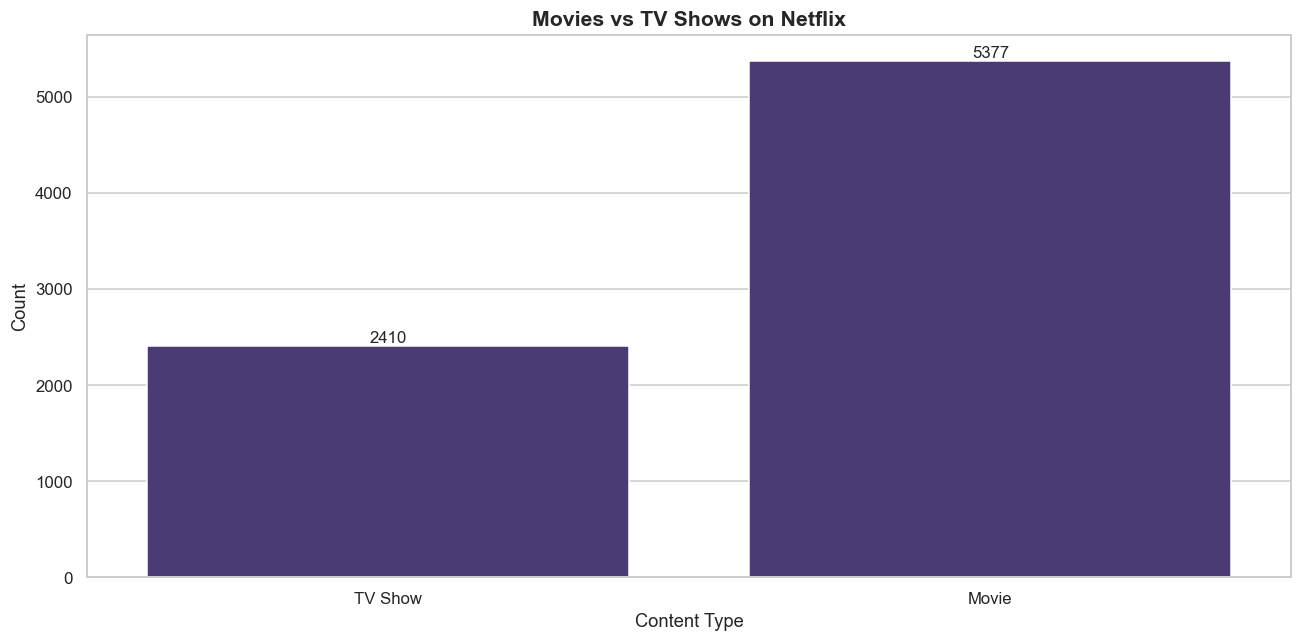

2026-05-15 23:12:22,959 | INFO | Saved → 01_movies_vs_tvshows.png


In [9]:
# 1. Movies vs TV Shows
fig, ax = plt.subplots()
sns.countplot(data=df, x='Category', ax=ax)
ax.set_title('Movies vs TV Shows on Netflix', fontsize=14, fontweight='bold')
ax.set_xlabel('Content Type'); ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
save_plot('01_movies_vs_tvshows.png')

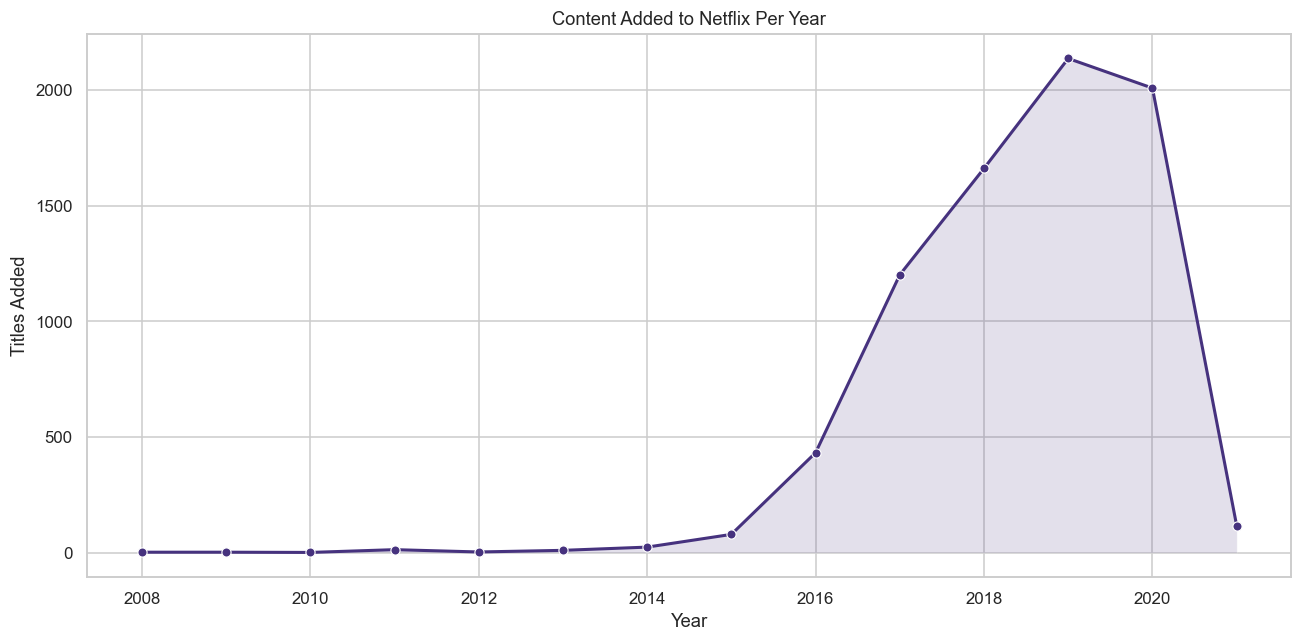

2026-05-15 23:12:23,155 | INFO | Saved → 02_yearly_trend.png


In [10]:
# 2. Content Added Per Year
yearly = df['Year_Added'].dropna().astype(int).value_counts().sort_index()
fig, ax = plt.subplots()
sns.lineplot(x=yearly.index, y=yearly.values, marker='o', linewidth=2, ax=ax)
ax.set(title='Content Added to Netflix Per Year', xlabel='Year', ylabel='Titles Added')
ax.fill_between(yearly.index, yearly.values, alpha=0.15)
save_plot('02_yearly_trend.png')

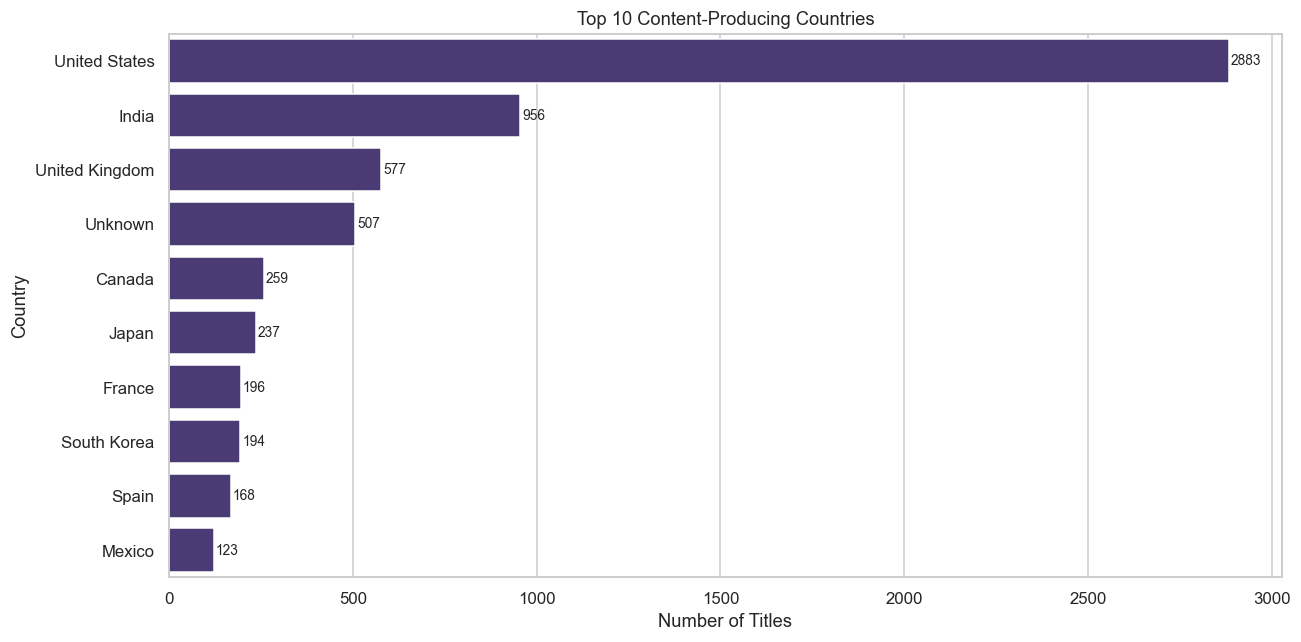

2026-05-15 23:12:23,370 | INFO | Saved → 03_top_countries.png


In [11]:
# 3. Top 10 Content-Producing Countries
top_countries = df['Main_Country'].value_counts().head(10)
fig, ax = plt.subplots()
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax)
ax.set(title='Top 10 Content-Producing Countries', xlabel='Number of Titles', ylabel='Country')
for i, v in enumerate(top_countries.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)
save_plot('03_top_countries.png')

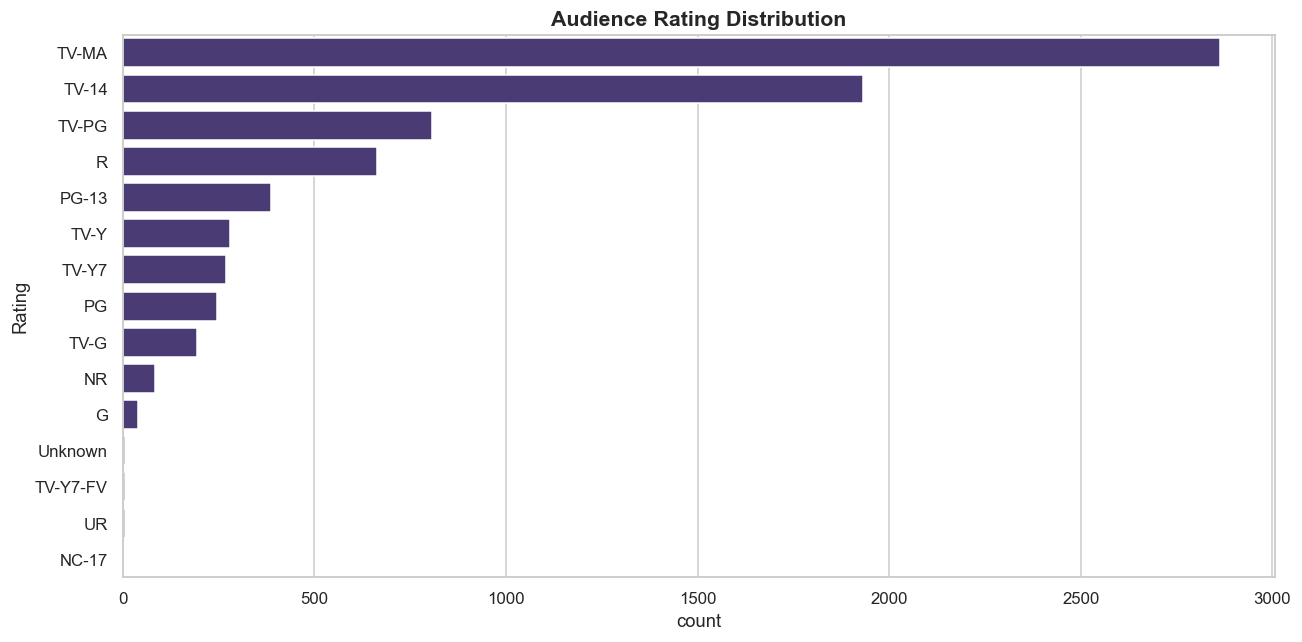

2026-05-15 23:12:23,601 | INFO | Saved → 04_ratings.png


In [12]:
# 4. Audience Rating Distribution
fig, ax = plt.subplots()
sns.countplot(data=df, y='Rating', order=df['Rating'].value_counts().index, ax=ax)
ax.set_title('Audience Rating Distribution', fontsize=14, fontweight='bold')
save_plot('04_ratings.png')

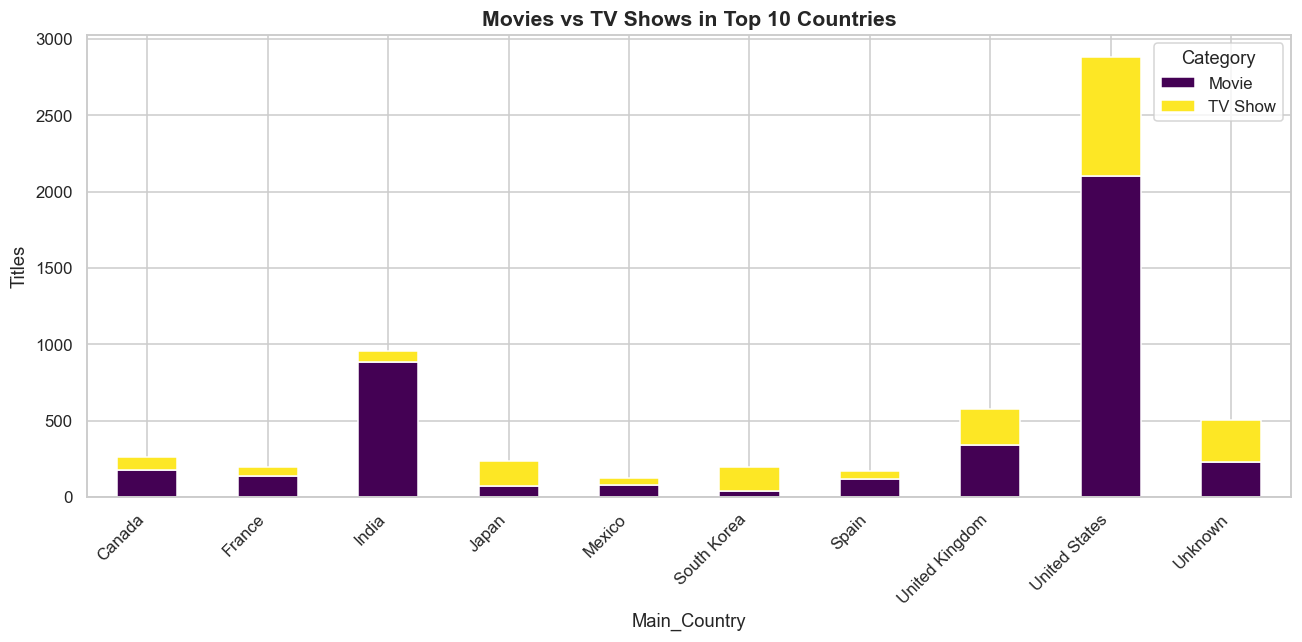

2026-05-15 23:12:23,856 | INFO | Saved → 05_country_category_stacked.png


In [13]:
# 5. Movies vs TV Shows by Top 10 Countries
top10 = df['Main_Country'].value_counts().head(10).index
subset = df[df['Main_Country'].isin(top10)]
pivot  = subset.groupby(['Main_Country', 'Category']).size().unstack(fill_value=0)
pivot.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 6))
plt.title('Movies vs TV Shows in Top 10 Countries', fontsize=14, fontweight='bold')
plt.ylabel('Titles'); plt.xticks(rotation=45, ha='right')
save_plot('05_country_category_stacked.png')

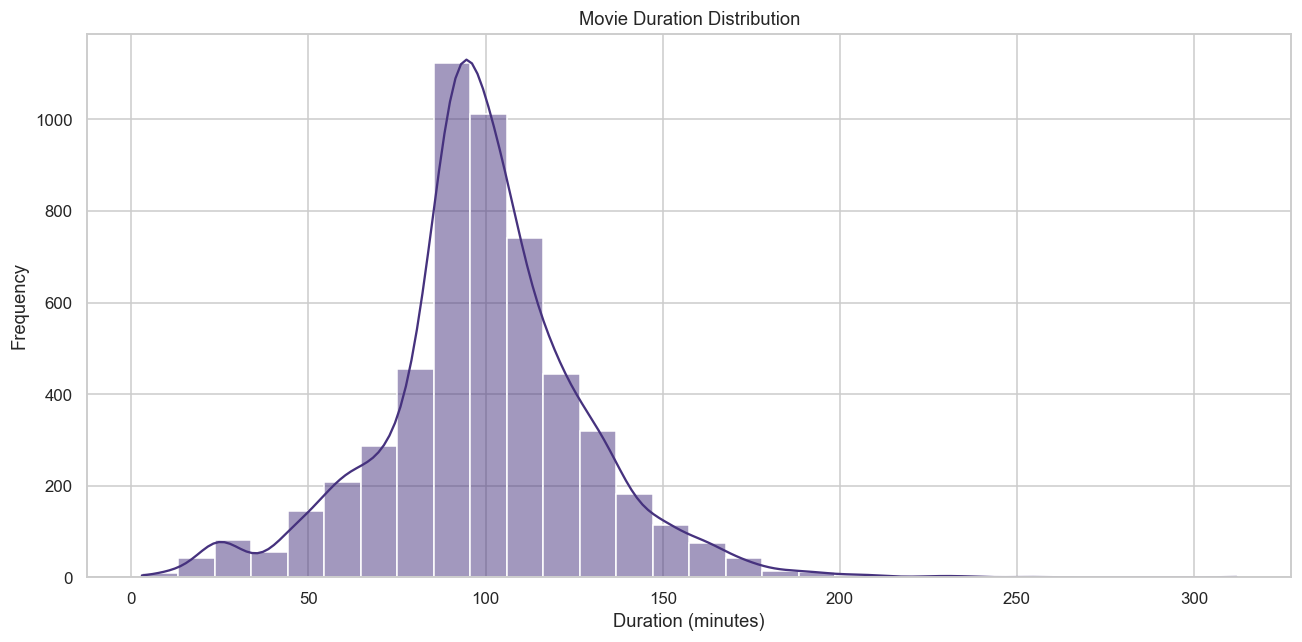

2026-05-15 23:12:24,120 | INFO | Saved → 06_movie_duration.png


In [14]:
# 6. Movie Duration Distribution
movies = df[df['Category'] == 'Movie'].copy()
movies['Duration_Min'] = (
    movies['Duration'].astype(str).str.extract(r'(\d+)').astype(float)
)
fig, ax = plt.subplots()
sns.histplot(movies['Duration_Min'].dropna(), bins=30, kde=True, ax=ax)
ax.set(title='Movie Duration Distribution', xlabel='Duration (minutes)', ylabel='Frequency')
save_plot('06_movie_duration.png')

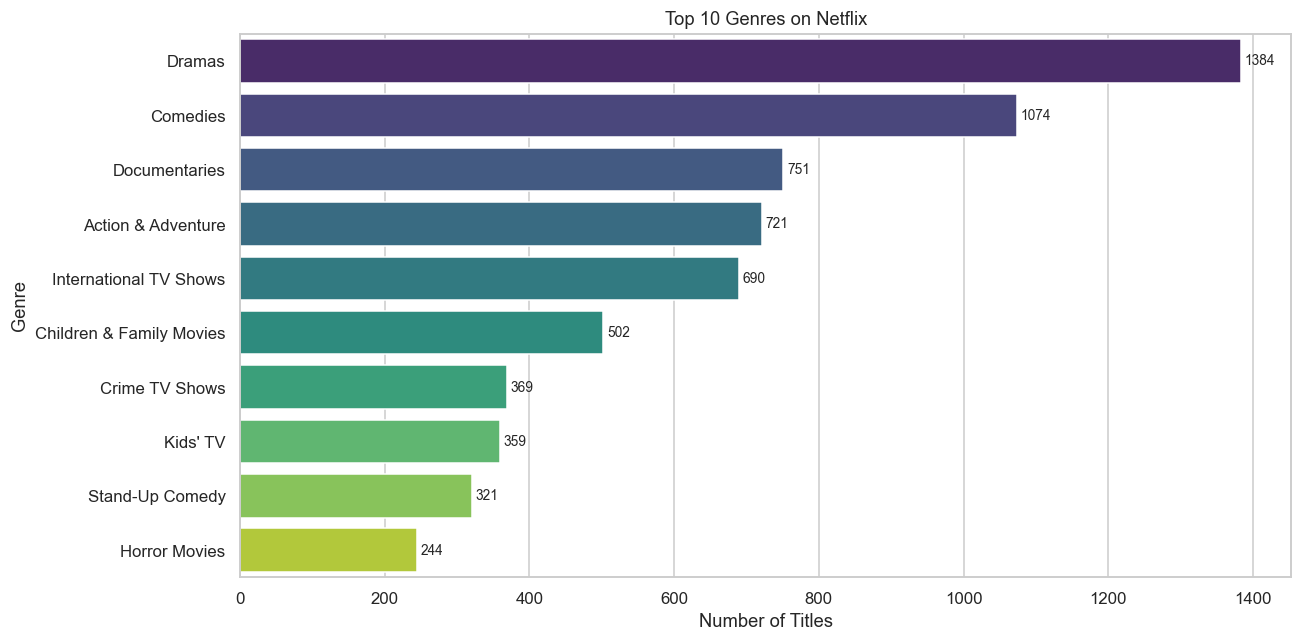

2026-05-15 23:12:24,398 | INFO | Saved → 07_top_genres.png


In [15]:
# 7. Top 10 genres
# 'Listed_In' contains comma-separated genres; explode to count each individually
genre_col = 'Listed_In' if 'Listed_In' in df.columns else 'Main_Genre'
genres     = df[genre_col].dropna().astype(str).str.split(',').explode().str.strip()
top_genres = genres.value_counts().head(10)

fig, ax = plt.subplots()
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis', ax=ax)
ax.set(title='Top 10 Genres on Netflix', xlabel='Number of Titles', ylabel='Genre')
for i, v in enumerate(top_genres.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)
save_plot('07_top_genres.png')

Interactive Visualization (Plotly)

In [16]:
# Interactive Choropleth Map
country_counts = df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']

fig = px.choropleth(
    country_counts,
    locations='Country',
    locationmode='country names',
    color='Count',
    hover_name='Country',
    color_continuous_scale='viridis',
    title='Netflix Content Distribution by Country'
)
fig.write_html(OUTPUT_DIR / '08_country_map.html')
fig.show()

In [17]:
# Interactive Monthly Release Heatmap
if 'Year_Added' in df.columns and 'Month_Added' in df.columns:
    heat_data = (
        df.dropna(subset=['Year_Added', 'Month_Added'])
          .groupby(['Year_Added', 'Month_Added'])
          .size()
          .reset_index(name='Count')
    )
    fig2 = px.density_heatmap(
        heat_data, x='Month_Added', y='Year_Added', z='Count',
        color_continuous_scale='viridis',
        title='Monthly Content Addition Heatmap'
    )
    fig2.write_html(OUTPUT_DIR / '09_monthly_heatmap.html')
    fig2.show()

WordCloud of Netflix Titles

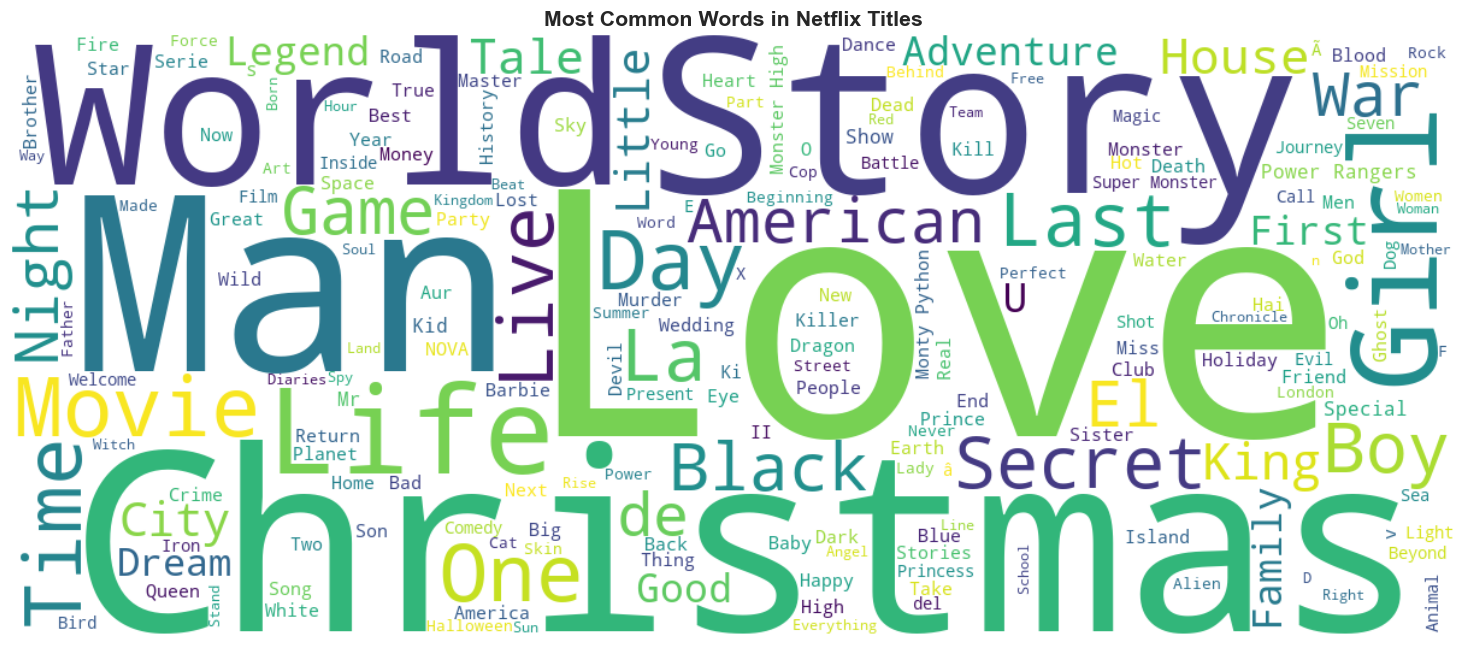

2026-05-15 23:12:27,308 | INFO | Saved → 10_wordcloud.png


In [18]:
text = ' '.join(df['Title'].dropna().astype(str))
wc   = WordCloud(width=1200, height=500, background_color='white',
                 colormap='viridis', max_words=200).generate(text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Titles', fontsize=14, fontweight='bold')
save_plot('10_wordcloud.png')

Content-Based Recommendation Engine

In [19]:
rec_df = df.dropna(subset=['Title']).reset_index(drop=True)
rec_df['Title'] = rec_df['Title'].astype(str)

def _col(name_options: list) -> pd.Series:
    """Return the first matching column, or an empty-string Series."""
    for name in name_options:
        if name in rec_df.columns:
            return rec_df[name].fillna('').astype(str)
    return pd.Series([''] * len(rec_df))

desc  = _col(['Description'])
genre = _col(['Listed_In', 'Main_Genre', 'Genres', 'Category'])
cast  = _col(['Cast', 'Director'])

rec_df['Tags'] = desc + ' ' + genre + ' ' + cast

tfidf  = TfidfVectorizer(stop_words='english', max_features=5000)
matrix = tfidf.fit_transform(rec_df['Tags'])
sim    = cosine_similarity(matrix)
log.info(f'Similarity matrix built: {sim.shape}')

2026-05-15 23:12:27,813 | INFO | Similarity matrix built: (7787, 7787)


In [20]:
def recommend(title: str, n: int = 5) -> pd.DataFrame:
    """ Return the top-n most similar Netflix titles. """
    matches = rec_df.index[rec_df['Title'].str.lower() == title.lower()]
    if len(matches) == 0:
        return f'❌  Title "{title}" not found in dataset.'
    idx    = matches[0]
    scores = sorted(enumerate(sim[idx]), key=lambda x: x[1], reverse=True)[1:n+1]
    cols   = [c for c in ['Title', 'Category', 'Main_Genre', 'Listed_In'] if c in rec_df.columns]
    return rec_df.iloc[[i for i, _ in scores]][cols].reset_index(drop=True)

sample_title = rec_df['Title'].iloc[0]
print(f'Recommendations similar to: "{sample_title}"\n')
recommend(sample_title)

Recommendations similar to: "0.03"



,Title,Category,Main_Genre
0,The Stranded,TV Show,International TV Shows
1,Kissing Game,TV Show,International TV Shows
2,Fire in Paradise,Movie,Documentaries
3,Blood Father,Movie,Action & Adventure
4,Mossad 101,TV Show,International TV Shows


Key Insights & Export

In [21]:
def safe_mode(series: pd.Series, label: str):
    """Return value_counts idxmax or 'N/A' if the series is empty."""
    s = series.dropna()
    return s.value_counts().idxmax() if not s.empty else 'N/A'

insights = {
    'Total titles'        : len(df),
    'Movies'              : int((df['Category'] == 'Movie').sum())   if 'Category'     in df.columns else 'N/A',
    'TV Shows'            : int((df['Category'] == 'TV Show').sum()) if 'Category'     in df.columns else 'N/A',
    'Top country'         : safe_mode(df.get('Main_Country', pd.Series()), 'Main_Country'),
    'Top genre'           : safe_mode(df.get('Main_Genre',   pd.Series()), 'Main_Genre'),
    'Most common rating'  : safe_mode(df.get('Rating',       pd.Series()), 'Rating'),
    'Peak year added'     : int(df['Year_Added'].dropna().astype(int).value_counts().idxmax())
                            if 'Year_Added' in df.columns and not df['Year_Added'].dropna().empty
                            else 'N/A',
}

print('\n' + '='*40)
print('   📊  KEY INSIGHTS')
print('='*40)
for k, v in insights.items():
    print(f'  {k:<22}: {v}')
print('='*40)

df.to_csv(OUTPUT_DIR / 'netflix_cleaned.csv', index=False)
pd.Series(insights).to_csv(OUTPUT_DIR / 'insights.csv', header=['Value'])
log.info('✅  Saved cleaned dataset and insights to outputs/')

2026-05-15 23:12:27,966 | INFO | ✅  Saved cleaned dataset and insights to outputs/



   📊  KEY INSIGHTS
  Total titles          : 7787
  Movies                : 5377
  TV Shows              : 2410
  Top country           : United States
  Top genre             : Dramas
  Most common rating    : TV-MA
  Peak year added       : 2019


In [22]:
# Export a 500-row sample for the live Streamlit demo
df.sample(500).to_csv('data/netflix_sample.csv', index=False)